# 04 — Compound Hazard Detection
**Project:** GB Compound Hazards Risk Prioritization

**Course:** Artificial Intelligence in Human Water Systems

---
## Objectives
- Identify spatiotemporal overlaps between precipitation and wind clusters
- Define compound hazard events following Tilloy et al. (2022)
- Assign compound events to NUTS1 regions of Great Britain
- Save compound hazard database for risk categorization

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Cluster Databases

In [2]:
rain_db = pd.read_parquet('../data/processed/rain_clusters_db.parquet')
wind_db = pd.read_parquet('../data/processed/wind_clusters_db.parquet')

print(f'Precipitation clusters: {len(rain_db):,}')
print(f'Wind clusters:          {len(wind_db):,}')
print('\nColumns:', list(rain_db.columns))

Precipitation clusters: 161
Wind clusters:          128

Columns: ['cluster_id', 'hazard_type', 'start_time', 'end_time', 'duration_h', 'n_points', 'n_cells', 'spatial_extent_km2', 'peak_intensity', 'mean_intensity', 'density', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'lat_centroid', 'lon_centroid', 'year', 'season']


## 3. Detect Compound Hazard Overlaps

A compound hazard event is identified when:
1. **Temporal overlap:** the time windows of a rain cluster and wind cluster overlap
2. **Spatial overlap:** the bounding boxes of both clusters intersect

Following Tilloy et al. (2022):
- Compound duration = union of both durations (OR)
- Compound footprint = intersection of both footprints (AND)

In [3]:
def check_spatial_overlap(r_lat_min, r_lat_max, r_lon_min, r_lon_max,
                           w_lat_min, w_lat_max, w_lon_min, w_lon_max):
    lat_overlap = r_lat_min <= w_lat_max and w_lat_min <= r_lat_max
    lon_overlap = r_lon_min <= w_lon_max and w_lon_min <= r_lon_max
    return lat_overlap and lon_overlap

compound_events = []
compound_id = 0

print(f'Checking {len(rain_db):,} precipitation x {len(wind_db):,} wind clusters...')

for _, rain_row in tqdm(rain_db.iterrows(), total=len(rain_db), desc='Processing rain clusters'):
    temporal_candidates = wind_db[
        (wind_db['start_time'] <= rain_row['end_time']) &
        (wind_db['end_time'] >= rain_row['start_time'])
    ]

    for _, wind_row in temporal_candidates.iterrows():
        if not check_spatial_overlap(
            rain_row['lat_min'], rain_row['lat_max'],
            rain_row['lon_min'], rain_row['lon_max'],
            wind_row['lat_min'], wind_row['lat_max'],
            wind_row['lon_min'], wind_row['lon_max']
        ):
            continue

        compound_start = min(rain_row['start_time'], wind_row['start_time'])
        compound_end   = max(rain_row['end_time'], wind_row['end_time'])
        compound_duration_h = (compound_end - compound_start).total_seconds() / 3600

        inter_lat_min = max(rain_row['lat_min'], wind_row['lat_min'])
        inter_lat_max = min(rain_row['lat_max'], wind_row['lat_max'])
        inter_lon_min = max(rain_row['lon_min'], wind_row['lon_min'])
        inter_lon_max = min(rain_row['lon_max'], wind_row['lon_max'])

        lat_span = inter_lat_max - inter_lat_min
        lon_span = inter_lon_max - inter_lon_min
        n_cells_approx = max(1, int((lat_span / 0.25) * (lon_span / 0.25)))
        cell_area_km2 = (0.25 * 111) * (0.25 * 65)
        compound_extent_km2 = n_cells_approx * cell_area_km2

        month = compound_start.month
        if month in [12, 1, 2]:   season = 'DJF'
        elif month in [3, 4, 5]:  season = 'MAM'
        elif month in [6, 7, 8]:  season = 'JJA'
        else:                      season = 'SON'

        compound_events.append({
            'compound_id': compound_id,
            'rain_cluster_id': rain_row['cluster_id'],
            'wind_cluster_id': wind_row['cluster_id'],
            'compound_start': compound_start,
            'compound_end': compound_end,
            'compound_duration_h': compound_duration_h,
            'compound_extent_km2': compound_extent_km2,
            'peak_precipitation_mm': rain_row['peak_intensity'],
            'peak_wind_ms': wind_row['peak_intensity'],
            'mean_precipitation_mm': rain_row['mean_intensity'],
            'mean_wind_ms': wind_row['mean_intensity'],
            'rain_duration_h': rain_row['duration_h'],
            'wind_duration_h': wind_row['duration_h'],
            'lat_min': inter_lat_min,
            'lat_max': inter_lat_max,
            'lon_min': inter_lon_min,
            'lon_max': inter_lon_max,
            'lat_centroid': (inter_lat_min + inter_lat_max) / 2,
            'lon_centroid': (inter_lon_min + inter_lon_max) / 2,
            'year': compound_start.year,
            'season': season
        })
        compound_id += 1

compound_db = pd.DataFrame(compound_events)
print(f'\nCompound hazard events detected: {len(compound_db):,}')

Checking 161 precipitation x 128 wind clusters...


Processing rain clusters: 100%|██████████| 161/161 [00:00<00:00, 204.84it/s]


Compound hazard events detected: 85


In [6]:
# Convert normalized centroids back to real coordinates
# lat: 0 units = 47.0°N, 1 unit = 0.25°
# lon: 0 units = -7.0°E, 1 unit = 0.25°
compound_db['lat_centroid'] = compound_db['lat_centroid'] * 0.25 + 47.0
compound_db['lon_centroid'] = compound_db['lon_centroid'] * 0.25 + (-7.0)
compound_db['lat_min'] = compound_db['lat_min'] * 0.25 + 47.0
compound_db['lat_max'] = compound_db['lat_max'] * 0.25 + 47.0
compound_db['lon_min'] = compound_db['lon_min'] * 0.25 + (-7.0)
compound_db['lon_max'] = compound_db['lon_max'] * 0.25 + (-7.0)

print('Corrected centroid ranges:')
print(f'  lat_centroid: {compound_db["lat_centroid"].min():.2f} to {compound_db["lat_centroid"].max():.2f}')
print(f'  lon_centroid: {compound_db["lon_centroid"].min():.2f} to {compound_db["lon_centroid"].max():.2f}')

Corrected centroid ranges:
  lat_centroid: 47.03 to 50.22
  lon_centroid: -6.91 to -4.56


## 4. Assign NUTS1 Regions

In [9]:
# Assign region based on which NUTS1 region has most overlap with cluster bbox
NUTS1_REGIONS = {
    'Scotland':                  (54.6, 60.0, -7.0,  3.0),
    'Wales':                     (51.3, 53.4, -5.3, -2.6),
    'North East England':        (54.5, 55.8, -2.4,  3.0),
    'North West England':        (53.3, 55.0, -7.0, -1.7),
    'Yorkshire and The Humber':  (53.3, 54.6, -2.6,  3.0),
    'East Midlands':             (52.2, 53.5, -1.8,  3.0),
    'West Midlands':             (51.9, 53.2, -7.0, -1.1),
    'East of England':           (51.5, 53.2,  0.0,  3.0),
    'London':                    (51.3, 51.7, -0.5,  0.3),
    'South East England':        (50.7, 51.9, -1.8,  3.0),
    'South West England':        (47.0, 51.8, -7.0,  0.0)
}

def assign_nuts1_region(lat_min, lat_max, lon_min, lon_max):
    best_region = 'Outside GB'
    best_overlap = 0
    
    for region, (r_lat_min, r_lat_max, r_lon_min, r_lon_max) in NUTS1_REGIONS.items():
        # Calculate overlap area
        overlap_lat = max(0, min(lat_max, r_lat_max) - max(lat_min, r_lat_min))
        overlap_lon = max(0, min(lon_max, r_lon_max) - max(lon_min, r_lon_min))
        overlap = overlap_lat * overlap_lon
        
        if overlap > best_overlap:
            best_overlap = overlap
            best_region = region
    
    return best_region

compound_db['nuts1_region'] = compound_db.apply(
    lambda row: assign_nuts1_region(
        row['lat_min'], row['lat_max'],
        row['lon_min'], row['lon_max']
    ), axis=1
)

print('Compound events per NUTS1 region:')
print(compound_db['nuts1_region'].value_counts().to_string())

Compound events per NUTS1 region:
nuts1_region
South West England    73
Outside GB            12


## 5. Compound Events Summary

In [10]:
print('=== Compound Hazard Events Summary ===')
print(compound_db[[
    'compound_duration_h', 'compound_extent_km2',
    'peak_precipitation_mm', 'peak_wind_ms'
]].describe().round(3))

print('\nCompound events per season:')
print(compound_db.groupby('season').size().to_string())

=== Compound Hazard Events Summary ===
       compound_duration_h  compound_extent_km2  peak_precipitation_mm  \
count               85.000               85.000                 85.000   
mean                16.329            30159.761                  4.587   
std                  7.180            62881.144                  1.680   
min                  3.000              450.938                  1.911   
25%                 11.000             1803.750                  3.542   
50%                 16.000             5411.250                  4.275   
75%                 22.000            19841.250                  5.204   
max                 36.000           360750.000                 10.608   

       peak_wind_ms  
count        85.000  
mean         23.696  
std           4.708  
min          16.756  
25%          20.218  
50%          22.896  
75%          26.652  
max          36.566  

Compound events per season:
season
SON    85


## 6. Visualize Compound Events per Region

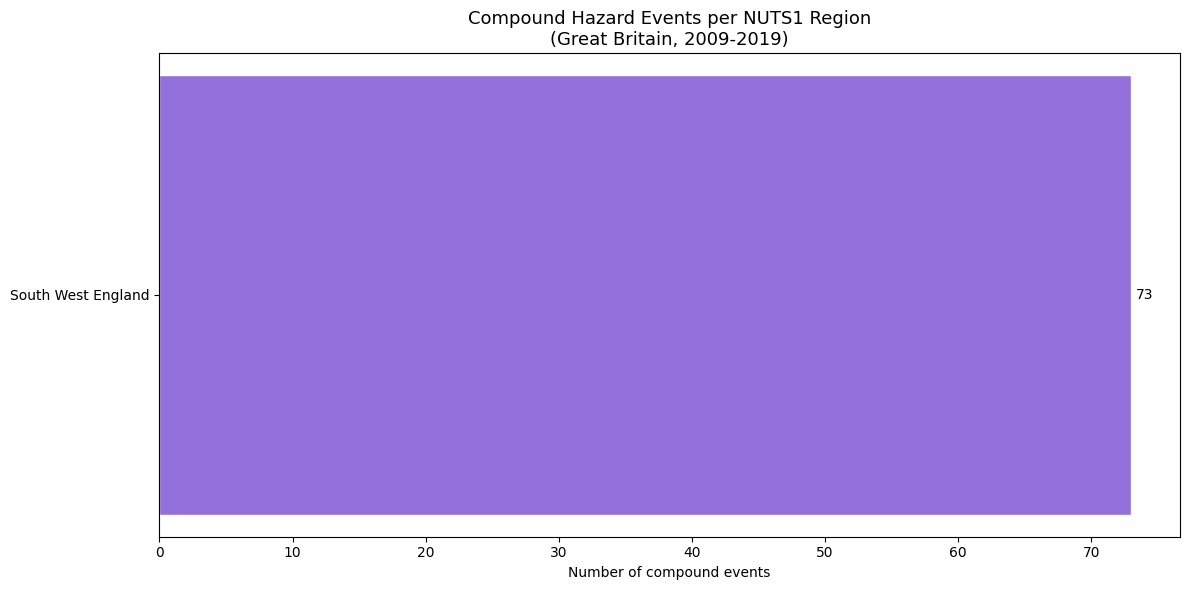

Figure saved!


In [11]:
region_counts = compound_db[compound_db['nuts1_region'] != 'Outside GB']['nuts1_region'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(region_counts.index, region_counts.values, color='mediumpurple', edgecolor='white')
ax.set_title('Compound Hazard Events per NUTS1 Region\n(Great Britain, 2009-2019)', fontsize=13)
ax.set_xlabel('Number of compound events')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('../outputs/figures/04_compound_events_per_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## 7. Save Compound Database

In [12]:
compound_db.to_parquet('../data/processed/compound_hazards_db.parquet', index=False)
compound_db.to_csv('../data/processed/compound_hazards_db.csv', index=False)

print(f'Saved compound_hazards_db with {len(compound_db):,} events')
print('  data/processed/compound_hazards_db.parquet')
print('  data/processed/compound_hazards_db.csv')

Saved compound_hazards_db with 85 events
  data/processed/compound_hazards_db.parquet
  data/processed/compound_hazards_db.csv
